## Imports 

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

## Load Data

In [109]:
df_raw = pd.read_csv("../data/EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv")
df_raw.head(3)

,OBJECTID,GEOID10,GEOID20,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CSA,CSA_Name,CBSA,...,D5DRI,D5DE,D5DEI,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked,NatWalkInd,Shape_Length,Shape_Area
0,1,4.811300e+11,4.811300e+11,48,113,7825,4,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.184697,0.000476,0.137707,6,14,15,17,14.000000,3110.360820,297836.0831
1,2,4.811300e+11,4.811300e+11,48,113,7825,2,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.323221,0.000801,0.231868,3,10,12,14,10.833333,3519.469110,484945.1466
2,3,4.811300e+11,4.811300e+11,48,113,7825,3,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.314628,0.000736,0.213146,1,1,7,17,8.333333,1697.091802,106705.9281


In [111]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 220740 entries, 0 to 220739
Columns: 117 entries, OBJECTID to Shape_Area
dtypes: float64(73), int64(42), str(2)
memory usage: 206.9 MB


## Keep Relevant Columns

In [113]:
# Keep Relevant Columns

cols_to_keep = [
    # Geographic Identifiers
    'GEOID10', # Census block group 12-digit FIPS code (2010)
    'GEOID20', # Census block group 12-digit FIPS code (2018)
    'CBSA', # FIPS for Core-Based Statistical Area (CBSA) in which CBG resides
    'CBSA_Name', # Name of CBSA in which CBG resides

    # Candidate Response Variable(s)
    'D5AR', # Jobs within 45 minutes auto travel time,
    'D5BR', # Jobs within 45-minute transit commute,
    
    # Transit Predictors
    'D4A', # Distance from the population-weighted centroid to nearest transit stop (meters)
    'D4C', # Aggregate frequency of transit service within 0.25 miles of CBG boundary per hour during evening peak period
    'D4D', # Aggregate frequency of transit service [D4c] per square mile
    'D4E', # Aggregate frequency of transit service [D4c] per capita
    
    # Other Variables/Controls
    
    ## Demographics
    'TotPop', # Population, 2018
    'HH', # Households (occupied housing units), 2018
    'P_WrkAge', # Percent of population that is working aged 18 to 64 years,
    'Pct_AO0',  # zero-car households (equity weight)
    'Workers', # Count of workers in CBG (home location), 2017
    'R_PCTLOWWAGE', # Percent of low wage workers in a CBG (home location), 2017
    
    ## Employment
    'TotEmp', # Total employment, 2017
    
    ## Density (D1)
    'D1B', # Gross population density (people/acre)
    'D1C', # Gross employment density (jobs/acre)
    
    ## Design (D3)
    'D3A', # Total road network density
    'D3B', # Street intersection density (weighted, auto-oriented intersections eliminated)
]

df_select = df_raw.copy()
df_select = df_select[cols_to_keep]
df_select.head(3)

,GEOID10,GEOID20,CBSA,CBSA_Name,D5AR,D5BR,D4A,D4C,D4D,D4E,...,HH,P_WrkAge,Pct_AO0,Workers,R_PCTLOWWAGE,TotEmp,D1B,D1C,D3A,D3B
0,4.811300e+11,4.811300e+11,19100.0,"Dallas-Fort Worth-Arlington, TX",433601,135362,362.10,4.33,37.654717,0.003602,...,423.0,0.549,0.163121,412,0.240291,66,16.332625,0.896800,23.534900,115.981747
1,4.811300e+11,4.811300e+11,19100.0,"Dallas-Fort Worth-Arlington, TX",386504,236885,718.84,4.33,23.126113,0.006099,...,409.0,0.466,0.000000,395,0.192405,25,5.955666,0.209707,22.893366,80.145600
2,4.811300e+11,4.811300e+11,19100.0,"Dallas-Fort Worth-Arlington, TX",404573,230587,398.31,3.00,72.818150,0.004071,...,329.0,0.811,0.057751,463,0.293737,0,27.951553,0.000000,14.210509,24.272717


## Look for missing, zero, negative, extreme values

In [114]:
# Look for missing, zero, negative, extreme values

summary = pd.DataFrame({
    "missing_%": df_select.isna().mean() * 100,
    "zeros_%": (df_select == 0).mean() * 100,
    "-99999_%": (df_select == -99999).mean() * 100,
    "min": df_select.min(numeric_only=True),
    "median": df_select.median(numeric_only=True),
    "max": df_select.max(numeric_only=True),
})

summary.sort_values("missing_%", ascending=False)

,missing_%,zeros_%,-99999_%,min,median,max
CBSA,7.744405,0.000000,0.000000,1.010000e+04,3.282000e+04,4.982000e+04
CBSA_Name,7.744405,0.000000,0.000000,NaN,NaN,NaN
HH,0.124581,0.713509,0.000000,0.000000e+00,4.760000e+02,2.133700e+04
D4D,0.000453,0.000000,54.053638,-9.999900e+04,-9.999900e+04,6.432396e+04
GEOID10,0.000453,0.000000,0.000000,1.001020e+10,2.901900e+11,7.803100e+11
D4E,0.000453,0.132282,54.053638,-9.999900e+04,-9.999900e+04,1.814433e+02
D3A,0.000000,0.430371,0.000000,0.000000e+00,1.562029e+01,1.668945e+02
D1B,0.000000,0.523240,0.000000,0.000000e+00,4.320753e+00,3.133578e+03
D1C,0.000000,2.340763,0.000000,0.000000e+00,5.336295e-01,1.403276e+04
D4C,0.000000,0.000000,54.054091,-9.999900e+04,-9.999900e+04,9.736700e+02


## Notes
- D4A, D4C, D4D, D4E, D5BR variables all have high % of '-99999' values
- According to the SLD User Guide:
    - **Distance to Nearest Transit (D4a)**: Distance to the nearest transit stop 'D4a' measures the minimum walk distance in meters between the 2010 population-weighted CBG centroid (as used by SLD version 2.0) and the nearest transit stop of any route type. **All CBGs with population-weighted centroids that were further than three-quarter miles from a transit stop were assigned a value of '-99999'**.
    - **Aggregate Frequency of Peak Hour Transit Service (D4c)**: GTFS transit schedule information was analyzed to calculate the frequency of service for each transit route during the weekday evening peak hour (4:00PM and 7:00PM local time). Transit routes with service that stops within 0.4 km (0.25 miles) crow-fly distance from the boundary of the CBG were then identified. Lastly, total aggregate service frequency was summed by CBG. Values for this metric are expressed as service frequency per hour of service. **CBGs in areas that do not have transit service were assigned the value “-99999.”**
    - **Aggregate Frequency of Peak Hour Transit Service Density (D4d)**: This measure applies density characteristics to aggregate transit service frequency per square mile. This metric was calculated by dividing aggregate transit service frequency [D4c] by total land acreage [Ac_Land], then converting to units per square mile. In a few instances where a CBG had no land acreage ([Ac_Land] = 0), total CBG polygon acreage [Ac_Total] was used as the denominator. **CBGs in areas that did not have transit service were given the value “-99999.”**
    - **Aggregate Frequency of Peak Hour Transit Service per Capita (D4e)**: Aggregate transit service frequency per capita [D4e] divides aggregate transit frequency [D4c] by total population [TotPop]. In the few instances where there was transit access and no population ([TotPop] = 0), the per capita transit access was set to 0. All **CBGs in areas where GTFS service data were unavailable were assigned a value of “-99999.”**
    - **Destination Accessibility via Transit (D5b)**: Transit accessibility was assessed in essentially the same way as auto accessibility, although the development of CBG to CBG OD matrices was more complex.
        -  Due to access to transit either not available (no transit service exists or transit service not producing GTFS data) or beyond the 0.75 mile (1,207 m) threshold in many CBGs in the country, **any CBG given a “-99999” value was ranked in the first quantile**. As a result, ranked CBGs only comprise rank 1 (without nearby transit service) and 15-20.

## Interpretation and Handling
- For the **response variable, 'D5BR'**, higher values mean more access. '-99999' values mean no transit access or no data. As we are modeling transit access *given that access exists*, we will **drop rows with values of '-99999'** to maintain meaninful regression results.
- For the **predictor variable 'D4a'**, lower values mean better access. '-99999' values mean no transit within 0.75 miles, so we will **set rows with values of '-99999' to NA and add an indicator**.
- For the **predictor variable 'D4c'**, higher values are better. '-99999' values mean -99999 means no service or no valid data, so **we will set these values to 0**.
- We will handle the **predictor variable 'D4d'** the same as 'D4c', since higher values are better.
- We will handle the **predictor variable 'D4e'** the same as 'D4c', since higher values are better.

**By dropping rows, we can now examine how 

In [156]:
# For response variable 'D5BR', drop rows with no transit access / no valid outcome
df_clean = df_select.copy()
df_clean = df_clean[df_clean['D5BR'] != -99999].copy()

# For 'D4A', set rows with no nearby transit to NA and add indicator
df_clean["D4A_no_transit"] = (df_clean["D4A"] == -99999).astype(int)
df_clean["D4A"] = df_clean["D4A"].replace(-99999, np.nan)

# For 'D4C', 'D4D', and 'D4E', set sentinel values to 0 and add indicator
for col in ["D4C", "D4D", "D4E"]:
    df_clean[col + "_no_transit"] = (df_clean[col] == -99999).astype(int)
    df_clean[col] = df_clean[col].replace(-99999, 0)

In [158]:
# Check again for missing, zero, negative, extreme values

summary = pd.DataFrame({
    "missing_%": df_clean.isna().mean() * 100,
    "zeros_%": (df_clean == 0).mean() * 100,
    "-99999_%": (df_clean == -99999).mean() * 100,
    "min": df_clean.min(numeric_only=True),
    "median": df_clean.median(numeric_only=True),
    "max": df_clean.max(numeric_only=True),
})

summary.sort_values("missing_%", ascending=False)

,missing_%,zeros_%,-99999_%,min,median,max
CBSA,0.278143,0.000000,0.0,1.014000e+04,3.498000e+04,4.974000e+04
CBSA_Name,0.278143,0.000000,0.0,NaN,NaN,NaN
D1B,0.000000,0.212323,0.0,0.000000e+00,1.023035e+01,3.133578e+03
D1C,0.000000,0.950147,0.0,0.000000e+00,1.732630e+00,1.403276e+04
D3A,0.000000,0.007431,0.0,0.000000e+00,2.271848e+01,1.527208e+02
D3B,0.000000,1.152915,0.0,0.000000e+00,1.067860e+02,5.289518e+03
D4A,0.000000,3.297380,0.0,0.000000e+00,3.996500e+02,1.207000e+03
D4A_no_transit,0.000000,100.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00
D4C,0.000000,6.352711,0.0,0.000000e+00,5.670000e+00,9.736700e+02
D4C_no_transit,0.000000,93.647289,0.0,0.000000e+00,0.000000e+00,1.000000e+00


## Check for Multicollinearity Between Predictors

In [182]:
pred_cols = ['D4A', 'D4C', 'D4D', 'D4E', 'TotPop', 'HH', 'P_WrkAge', 'Pct_AO0', 'Workers', 'R_PCTLOWWAGE', 'TotEmp', 'D1B', 'D1C', 'D3A', 'D3B']
df_clean[pred_cols].corr()

,D4A,D4C,D4D,D4E,TotPop,HH,P_WrkAge,Pct_AO0,Workers,R_PCTLOWWAGE,TotEmp,D1B,D1C,D3A,D3B
D4A,1.000000,-0.260256,-0.179748,-0.013656,0.140402,0.108134,-0.137552,-0.365246,0.171887,-0.101792,-0.027467,-0.230711,-0.067816,-0.352873,-0.244199
D4C,-0.260256,1.000000,0.693272,0.128629,0.005927,0.070511,0.149437,0.511550,0.016713,-0.140791,0.265286,0.390687,0.305923,0.290352,0.114568
D4D,-0.179748,0.693272,1.000000,0.044154,-0.035058,0.014935,0.087339,0.501197,-0.022883,-0.124221,0.032297,0.554572,0.201849,0.188940,-0.001942
D4E,-0.013656,0.128629,0.044154,1.000000,-0.023832,-0.021086,0.008033,0.026850,-0.019385,-0.004777,0.031264,0.009387,0.030573,0.024828,0.016553
TotPop,0.140402,0.005927,-0.035058,-0.023832,1.000000,0.839287,0.011170,-0.088657,0.858757,-0.102968,0.112867,0.069647,0.006226,-0.125518,-0.075578
HH,0.108134,0.070511,0.014935,-0.021086,0.839287,1.000000,0.114132,-0.006005,0.835755,-0.175840,0.171242,0.073822,0.026883,-0.109478,-0.087855
P_WrkAge,-0.137552,0.149437,0.087339,0.008033,0.011170,0.114132,1.000000,0.058357,0.100588,-0.132444,0.086801,0.093581,0.057533,0.164315,0.102374
Pct_AO0,-0.365246,0.511550,0.501197,0.026850,-0.088657,-0.006005,0.058357,1.000000,-0.125308,0.185644,0.040637,0.499727,0.140691,0.314490,0.126434
Workers,0.171887,0.016713,-0.022883,-0.019385,0.858757,0.835755,0.100588,-0.125308,1.000000,-0.240202,0.135299,0.024167,0.013043,-0.127869,-0.092609
R_PCTLOWWAGE,-0.101792,-0.140791,-0.124221,-0.004777,-0.102968,-0.175840,-0.132444,0.185644,-0.240202,1.000000,-0.072260,-0.082052,-0.050460,-0.051169,-0.021545


## Look at Variable Distributions

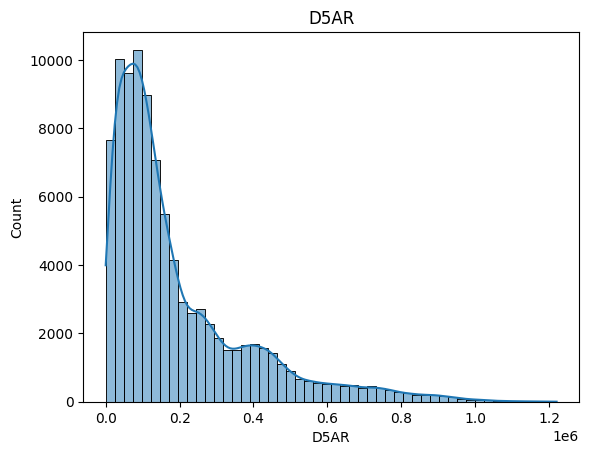

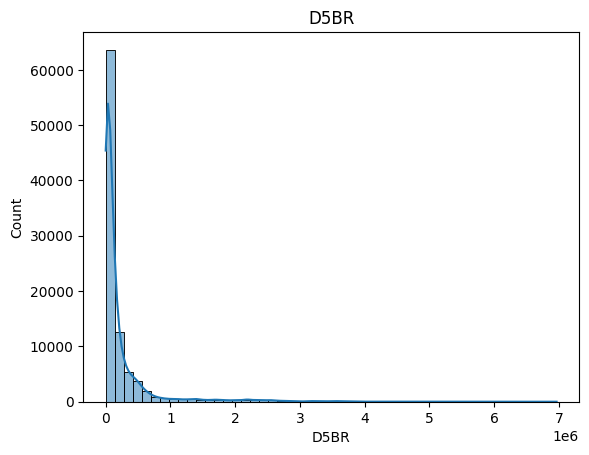

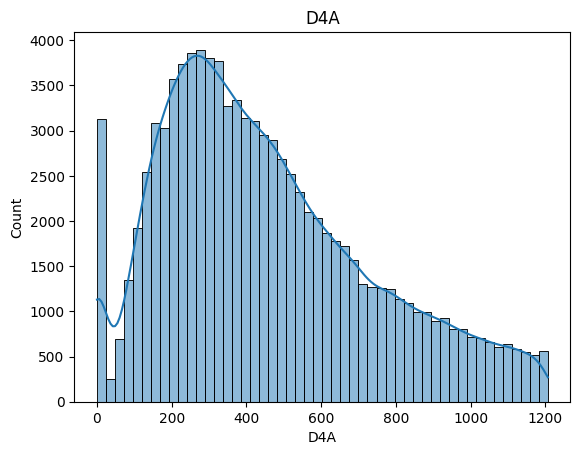

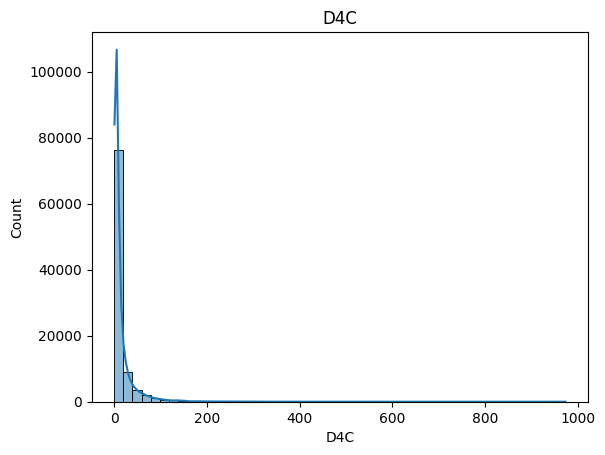

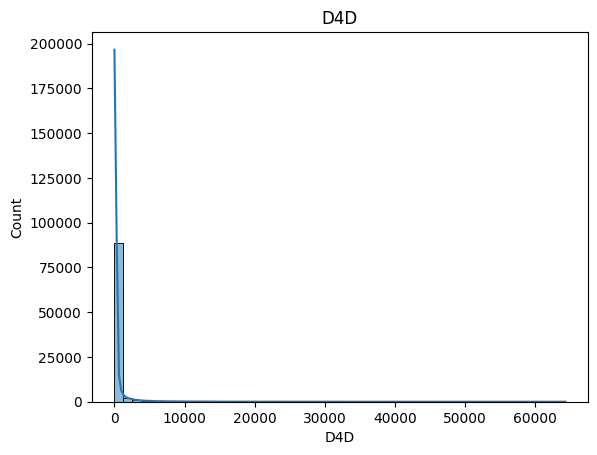

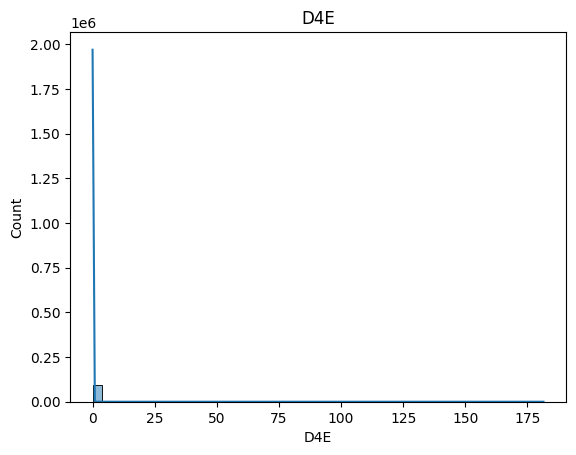

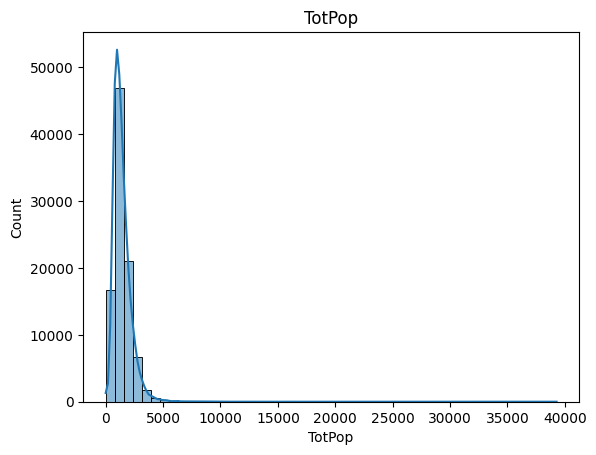

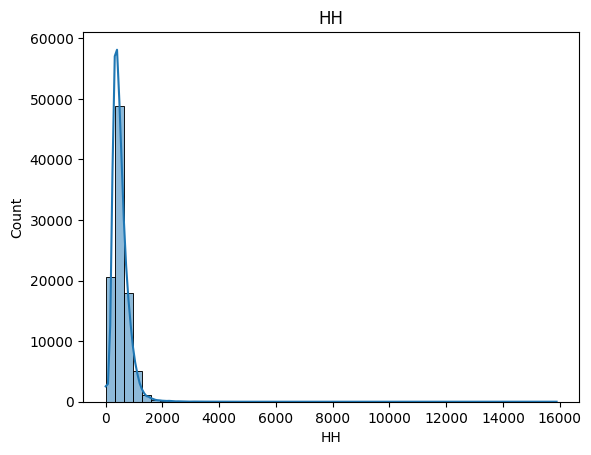

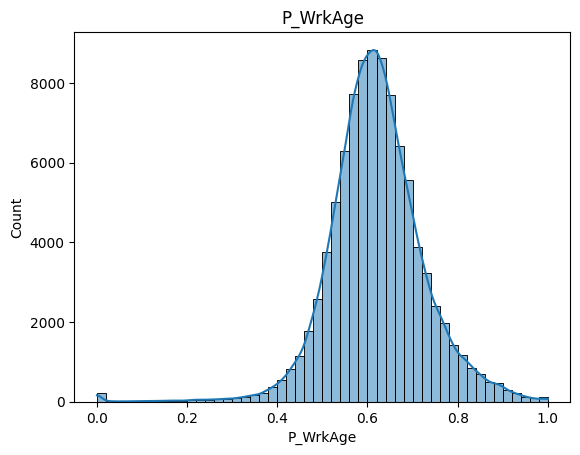

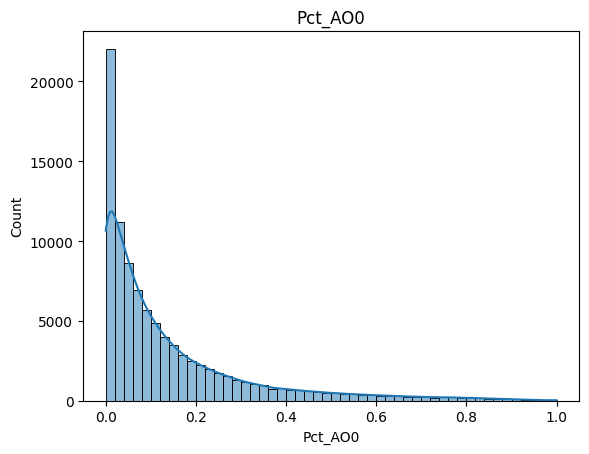

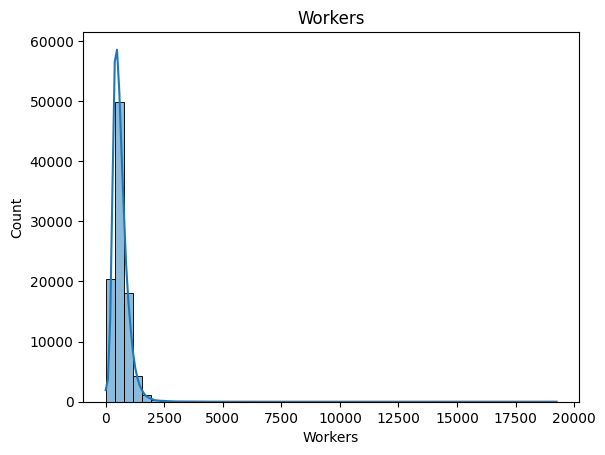

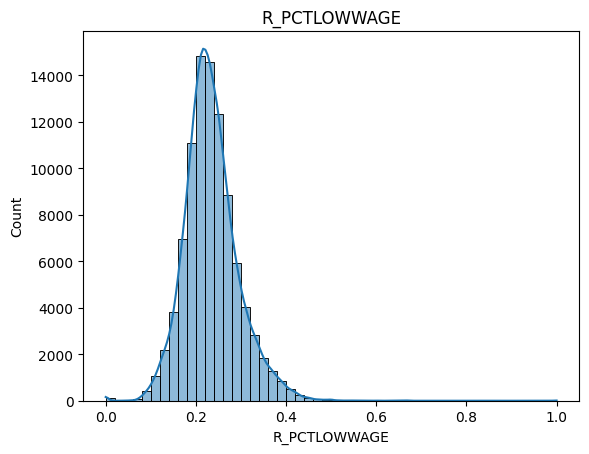

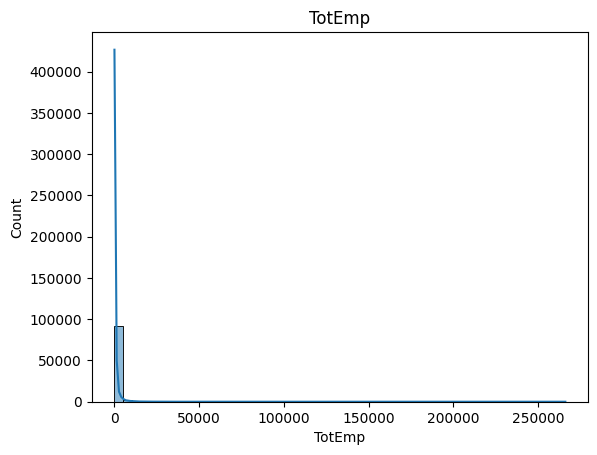

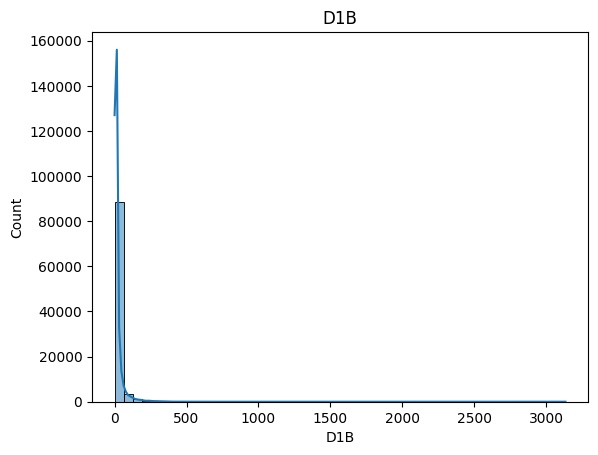

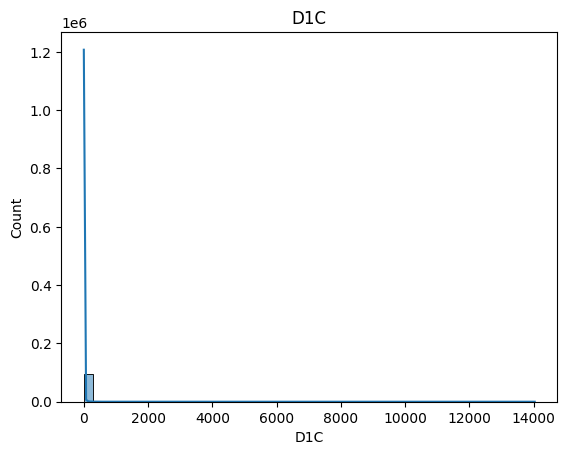

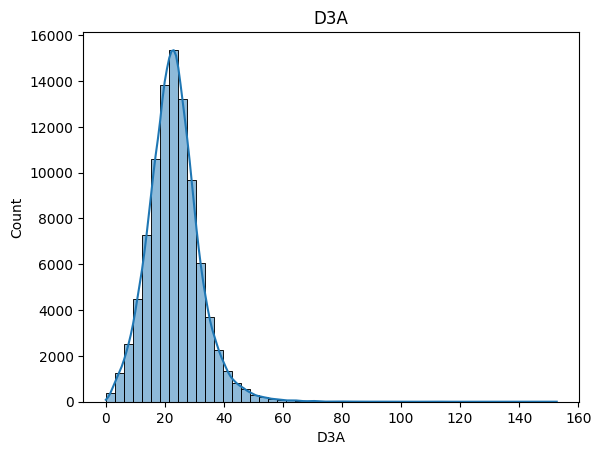

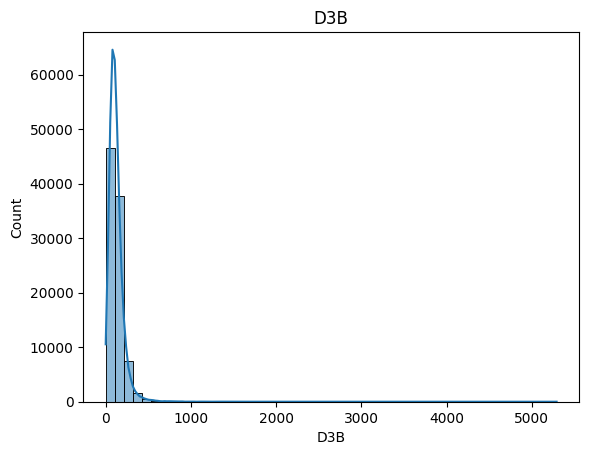

In [139]:
pred_cols = ['D5AR', 'D5BR', 'D4A', 'D4C', 'D4D', 'D4E', 'TotPop', 'HH', 'P_WrkAge', 'Pct_AO0', 'Workers', 'R_PCTLOWWAGE', 'TotEmp', 'D1B', 'D1C', 'D3A', 'D3B']
for col in pred_cols:
    sns.histplot(df_clean[col], bins=50, kde=True)
    plt.title(col)
    plt.show()

## Transform Highly Skewed Variables

In [174]:
log_cols = ["D5AR", "D5BR", "D4A", "TotEmp", "Workers", "TotPop", "HH","D1C", "D1B", "D3B"]

for col in log_cols:
    df_clean["log_" + col] = np.log1p(df_clean[col])

df_clean.columns

Index(['GEOID10', 'GEOID20', 'CBSA', 'CBSA_Name', 'D5AR', 'D5BR', 'D4A', 'D4C',
       'D4D', 'D4E', 'TotPop', 'HH', 'P_WrkAge', 'Pct_AO0', 'Workers',
       'R_PCTLOWWAGE', 'TotEmp', 'D1B', 'D1C', 'D3A', 'D3B', 'D4A_no_transit',
       'D4C_no_transit', 'D4D_no_transit', 'D4E_no_transit', 'log_D5AR',
       'log_D5BR', 'log_TotEmp', 'log_Workers', 'log_TotPop', 'log_HH',
       'log_D1C', 'log_D1B', 'log_D3B', 'log_D4A'],
      dtype='str')

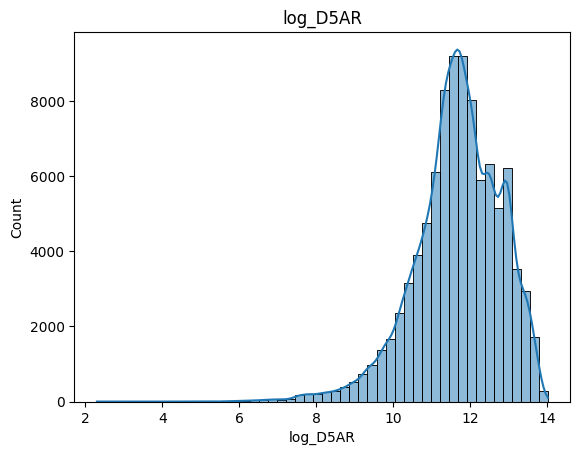

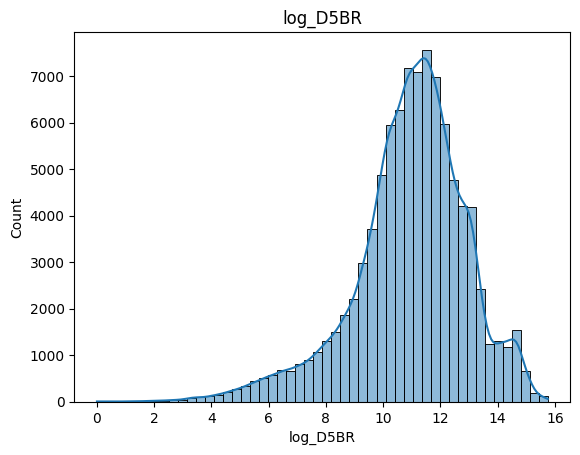

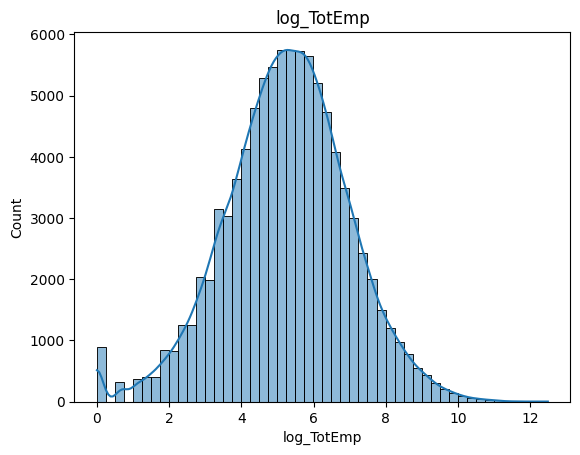

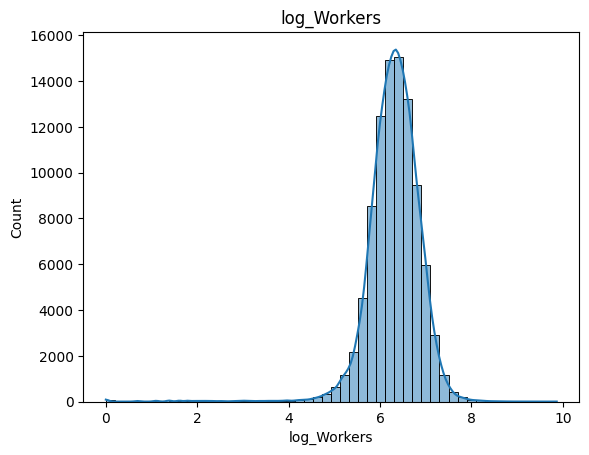

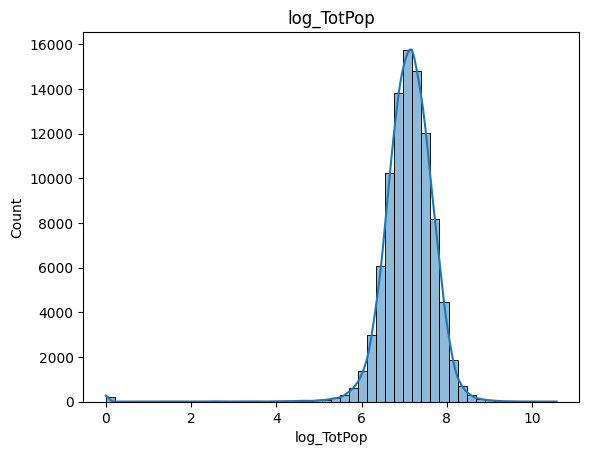

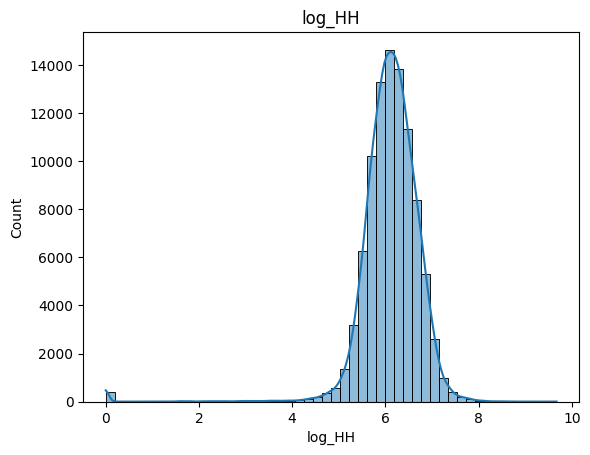

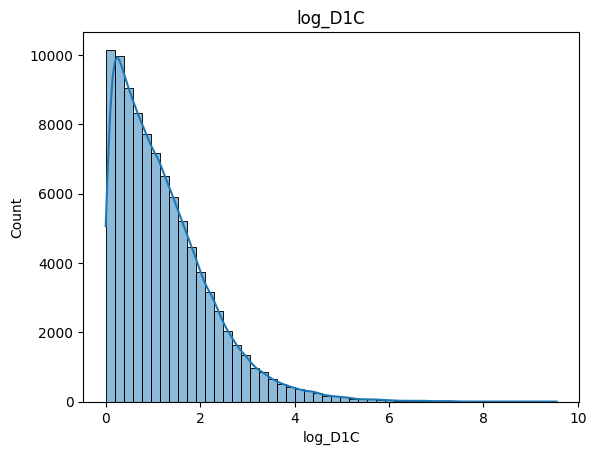

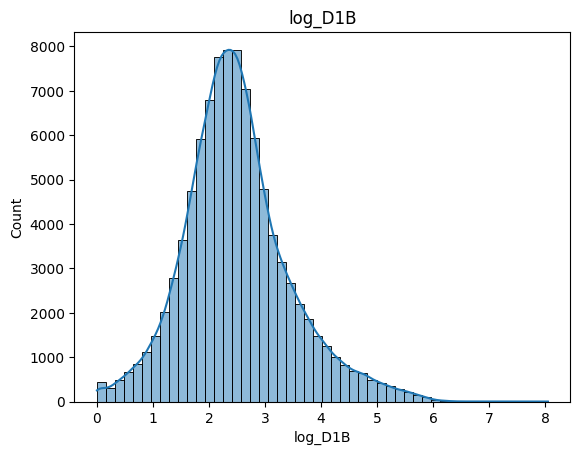

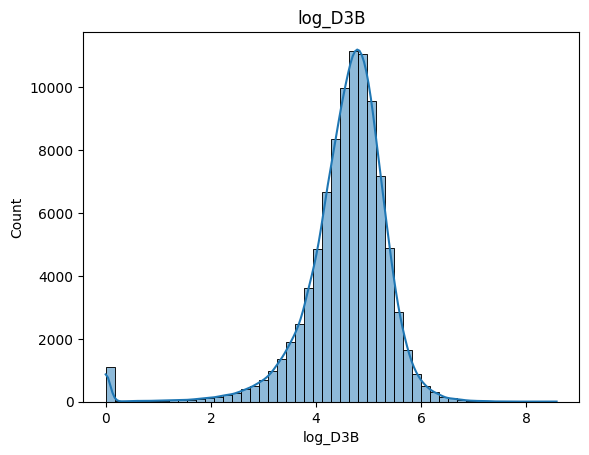

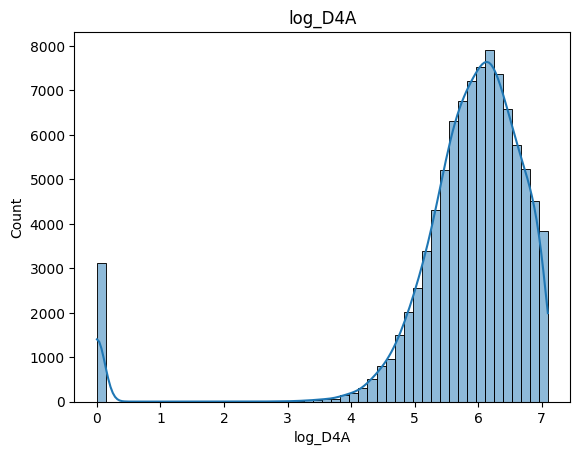

In [175]:
for col in ['log_D5AR','log_D5BR', 'log_TotEmp', 'log_Workers', 'log_TotPop', 'log_HH', 'log_D1C', 'log_D1B', 'log_D3B', 'log_D4A']:
    sns.histplot(df_clean[col], bins=50, kde=True)
    plt.title(col)
    plt.show()

## Check Again for Multicollinearity

In [186]:
vars_transformed = ['D4C', 'D4D', 'D4E', 'log_TotPop', 'log_HH', 'P_WrkAge', 'Pct_AO0', 'log_Workers', 'R_PCTLOWWAGE', 'log_TotEmp', 'log_D1B', 'log_D1C', 'D3A', 'log_D3B', 'log_D4A']

In [187]:
df_clean[vars_transformed].corr()

,D4C,D4D,D4E,log_TotPop,log_HH,P_WrkAge,Pct_AO0,log_Workers,R_PCTLOWWAGE,log_TotEmp,log_D1B,log_D1C,D3A,log_D3B,log_D4A
D4C,1.000000,0.693272,0.128629,-0.024610,0.003676,0.149437,0.511550,0.008229,-0.140791,0.139660,0.398361,0.482587,0.290352,-0.053598,-0.209546
D4D,0.693272,1.000000,0.044154,-0.033503,0.007579,0.087339,0.501197,-0.015129,-0.124221,0.008191,0.434747,0.361133,0.188940,-0.243518,-0.160988
D4E,0.128629,0.044154,1.000000,-0.080962,-0.072935,0.008033,0.026850,-0.037651,-0.004777,0.014002,-0.006893,0.039736,0.024828,0.000753,-0.009872
log_TotPop,-0.024610,-0.033503,-0.080962,1.000000,0.791010,0.124458,-0.070275,0.749904,-0.113332,0.199718,0.214722,0.008161,-0.102089,-0.036702,0.074401
log_HH,0.003676,0.007579,-0.072935,0.791010,1.000000,0.171829,0.010177,0.681111,-0.168925,0.221347,0.147236,0.059889,-0.098784,-0.057883,0.051478
P_WrkAge,0.149437,0.087339,0.008033,0.124458,0.171829,1.000000,0.058357,0.139898,-0.132444,0.085224,0.194059,0.209115,0.164315,0.084466,-0.080379
Pct_AO0,0.511550,0.501197,0.026850,-0.070275,0.010177,0.058357,1.000000,-0.118164,0.185644,-0.010580,0.522548,0.399374,0.314490,-0.040283,-0.281077
log_Workers,0.008229,-0.015129,-0.037651,0.749904,0.681111,0.139898,-0.118164,1.000000,-0.260289,0.246832,0.108011,0.039817,-0.104025,-0.041074,0.099969
R_PCTLOWWAGE,-0.140791,-0.124221,-0.004777,-0.113332,-0.168925,-0.132444,0.185644,-0.260289,1.000000,-0.135720,-0.103058,-0.158238,-0.051169,0.011560,-0.073072
log_TotEmp,0.139660,0.008191,0.014002,0.199718,0.221347,0.085224,-0.010580,0.246832,-0.135720,1.000000,-0.261359,0.708057,-0.122377,-0.076385,0.003852


## Define Final Variable Set (Drop highly collinear variables)

In [178]:
# Response
y = df_clean['log_D5BR'] # response

# Predictors
X = df_clean[
    [
        "log_D4A", "D4C", "D4D", "D4E", # transit
        "log_TotPop", # population
        "P_WrkAge", "Pct_AO0", "R_PCTLOWWAGE", # demographics
        "log_D1B", "log_D1C", # density
        "log_D3B", "D3A" # built environment
    ]
]